# 07 — Full 2D Vehicle Model

**What this notebook covers:**

| # | Concept | What's new vs notebook 06 |
|---|---------|---------------------------|
| 1 | Engine–wheel coupling | Throttle drives rear wheel angular velocity ω_r |
| 2 | Traction slip ratio | κ computed from ω_r — not prescribed |
| 3 | Wheel angular dynamics | Torque balance: engine tries to spin up, tyre resists |
| 4 | Auto gear changes | RPM tracks ω_r through gear ratio |
| 5 | Friction circle | Longitudinal + lateral forces share one tyre budget |
| 6 | Full maneuver | S-turn with throttle: weight transfer + aero + friction circle all at once |

**Prerequisites:** notebooks 01–06.

**This is the complete physics stack** — every concept from the series wired together.

---
## 1 — The missing piece: engine–wheel coupling

In notebooks 02–06, the longitudinal force came from a prescribed slip ratio:  
``κ_r = −brake × κ_peak × bias``  
The engine was never involved in the tyre physics.

The real chain of causality is:

```
throttle
   │
   ▼
engine torque  T_e = torque_curve(RPM)
   │
   ▼
wheel torque   T_w = T_e × GR × FDR
   │
   ▼
angular accel  dω_r/dt = (T_w/2 − F_x,r/2 × R) / I_wheel
   │                      ↑ tyre pushes back
   ▼
wheel speed    ω_r × R  (faster than Vx when spinning)
   │
   ▼
traction slip  κ = (ω_r·R − Vx) / max(ω_r·R, Vx)
   │
   ▼
Pacejka Fx     (peaks around κ ≈ 0.05; drops off at higher κ)
   │
   ├──► accelerates the car body  (Fx / M)
   └──► torque that brakes the wheel  (Fx × R in dω_r/dt)
```

This is a **self-regulating feedback loop**.  If the engine overshoots, the tyre force drops (past the Pacejka peak), which reduces wheel braking, which lets the wheel spin even faster — **wheelspin** spirals until the tyre operates far from peak.  A traction control system (TC) prevents this by cutting throttle when κ exceeds a threshold.

### Wheel rotational dynamics

The equation of motion for the rear wheel treated as a spinning flywheel:

$$I_{\text{wheel}} \frac{d\omega_r}{dt} = \frac{T_{\text{drive}}}{2} - \frac{F_{x,r}}{2} \cdot R$$

where the factor of 2 distributes torque/force equally between left and right rear wheels.

$I_{\text{wheel}} = 1.5 \, \text{kg·m}^2$ — this is the *effective* rotational inertia including the reflected drivetrain inertia (in low gear, even a light flywheel feels heavy because it is multiplied by gear ratio²).

In [1]:
import sys, os
sys.path.insert(0, os.path.join('lib'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from bicycle_model import (
    Full2DModel,
    M, G, A, B, IZ,
    C_DF, C_DR, AERO_BALANCE_F,
    I_WHEEL,
    FZ_F, FZ_R,
)
from engine import (
    torque_curve, get_wheel_force,
    GEAR_RATIOS, FINAL_DRIVE_RATIO, WHEEL_RADIUS,
    RPM_IDLE, RPM_REDLINE,
)

def to_h(model):
    """Convert model history to numpy arrays."""
    return {k: np.array(v) for k, v in model.history.items()}

print(f"Full2DModel ready.  I_wheel = {I_WHEEL} kg·m²")
print(f"Gear ratios: {GEAR_RATIOS}")

Full2DModel ready.  I_wheel = 1.5 kg·m²
Gear ratios: {'R': -2.5, 'N': 0.0, 1: 3.2, 2: 2.19, 3: 1.61, 4: 1.27, 5: 1.03, 6: 0.85, 7: 0.71, 8: 0.61}


---
## 2 — `Full2DModel` architecture

```
BicycleModel            ← pure lateral, constant Vx          (nb 03)
  └── CombinedBicycleModel  ← combined slip + dynamic Vx    (nb 04)
        └── WeightTransferModel  ← 4-wheel loads             (nb 05)
              └── AeroBicycleModel  ← downforce + drag       (nb 06)
                    └── Full2DModel  ← throttle + engine     (nb 07)
```

### What each step does (per timestep)

| Step | Operation |
|------|-----------|
| 1 | `F_down = c_df·Vx²`, `F_drag = c_dr·Vx²` |
| 2 | `F_roll = μ_roll·M·g` (rolling resistance, always opposes motion) |
| 3 | Per-tire Fz from static + long. WT + downforce + lat. WT (one-step lag) |
| 4 | Slip angles α_f, α_r from δ and yaw dynamics |
| 5 | `κ_r = (ω_r·R − Vx) / max(ω_r·R, Vx)` — traction slip from wheel state |
| 6 | `Fx, Fy` per axle via combined slip + load-sensitive Pacejka |
| 7 | Rear wheel dynamics: `dω_r/dt = (T_drive/2 − Fx_r/2·R) / I_wheel` |
| 8 | RPM ← ω_r × GR × FDR; auto-shift if RPM > 90 % / < 40 % of redline |
| 9 | `ax = (Fx_f + Fx_r − F_drag − F_roll) / M` |
| 10 | Euler integration of Vx, Vy, ψ̇, ψ, x, y |

---
## 3 — Straight-line acceleration (Monza low-DF setup)

We use the Monza (low downforce) setup for the acceleration test so drag doesn't cap top speed early.  
Starting at 10 m/s with full throttle — watch the engine struggle through the low-RPM desert,  
then explode once it hits the power band at ~9 000 RPM.

**Key numbers at the start:**
- Vx = 10 m/s → gear 1 RPM ≈ 3 000 RPM → torque ≈ 50 Nm (almost idle)
- Vx = 27 m/s → gear 1 RPM ≈ 8 000 RPM → torque ≈ 150 Nm (entering power band)
- Vx = 37 m/s → gear 1 RPM ≈ 11 000 RPM → torque ≈ 300 Nm (peak torque)

Gear change summary:
  t=10.27s  1→2  Vx=154.9 km/h  RPM=13495
  t=14.35s  2→3  Vx=230.0 km/h  RPM=13499
  t=25.58s  3→4  Vx=315.2 km/h  RPM=13500

Final state: 372.0 km/h  gear 4  RPM 12583


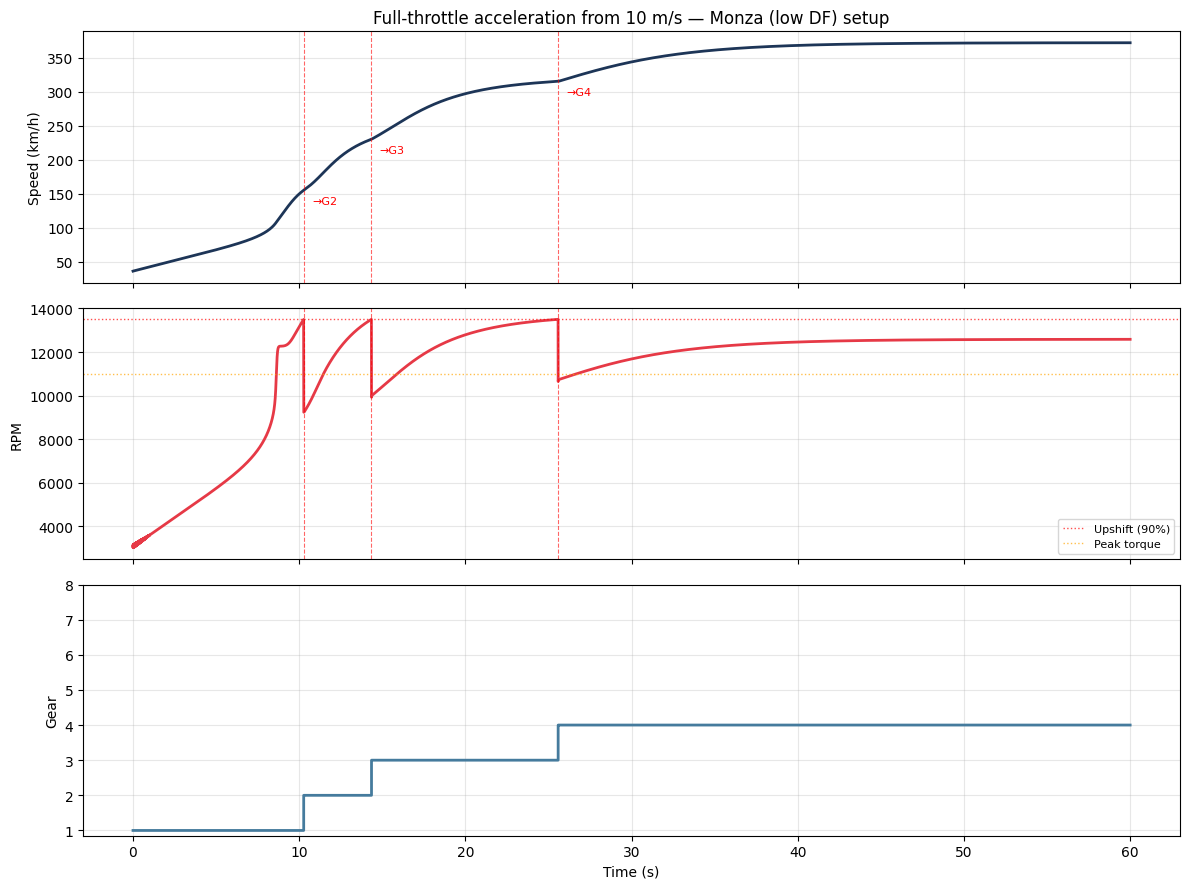

In [2]:
# Monza low-DF setup: less drag → higher top speed
m_accel = Full2DModel(Vx=10.0, c_df=0.70, c_dr=0.25)
T_SIM = 60.0
DT    = 0.005
N_STEPS = int(T_SIM / DT)

for _ in range(N_STEPS):
    m_accel.step(delta=0.0, throttle=1.0, brake=0.0, dt=DT)

ha = to_h(m_accel)

# Find gear change times
gear_arr = ha['gear'].astype(int)
shift_idx = np.where(np.diff(gear_arr) > 0)[0]

print("Gear change summary:")
for i in shift_idx:
    print(f"  t={ha['t'][i]:.2f}s  {gear_arr[i]}→{gear_arr[i+1]}  "
          f"Vx={ha['Vx'][i]*3.6:.1f} km/h  RPM={ha['rpm'][i]:.0f}")
print(f"\nFinal state: {ha['Vx'][-1]*3.6:.1f} km/h  gear {gear_arr[-1]}  RPM {ha['rpm'][-1]:.0f}")

# ── Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Velocity
ax = axes[0]
ax.plot(ha['t'], ha['Vx'] * 3.6, color='#1d3557', lw=2)
ax.set_ylabel('Speed (km/h)')
ax.set_title('Full-throttle acceleration from 10 m/s — Monza (low DF) setup')
ax.grid(True, alpha=0.3)
for i in shift_idx:
    ax.axvline(ha['t'][i], color='red', lw=0.8, ls='--', alpha=0.6)
    ax.annotate(f"→G{gear_arr[i+1]}",
                xy=(ha['t'][i], ha['Vx'][i]*3.6),
                xytext=(ha['t'][i]+0.5, ha['Vx'][i]*3.6 - 20),
                fontsize=8, color='red')

# RPM
ax = axes[1]
ax.plot(ha['t'], ha['rpm'], color='#e63946', lw=2)
ax.axhline(RPM_REDLINE * 0.90, color='red', lw=1, ls=':', alpha=0.7, label='Upshift (90%)')
ax.axhline(11000, color='orange', lw=1, ls=':', alpha=0.7, label='Peak torque')
ax.set_ylabel('RPM')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
for i in shift_idx:
    ax.axvline(ha['t'][i], color='red', lw=0.8, ls='--', alpha=0.6)

# Gear
ax = axes[2]
ax.step(ha['t'], ha['gear'], color='#457b9d', lw=2, where='post')
ax.set_ylabel('Gear')
ax.set_xlabel('Time (s)')
ax.set_yticks(range(1, 9))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4 — Traction slip: wheelspin and its self-limiting nature

The traction slip ratio κ tells us **how much faster the tyre contact patch is moving than the road**.  
- κ = 0 → perfect rolling, no slip
- κ = 0.05 → Pacejka longitudinal peak (maximum traction)
- κ > 0.10 → wheelspin — tyre force is dropping, energy is wasted as heat

In the first few seconds the wheel overspeeds (high κ, below-peak tyre force).  
As Vx catches up to wheel speed, κ drops toward the optimal range — this is the *self-limiting* feedback.

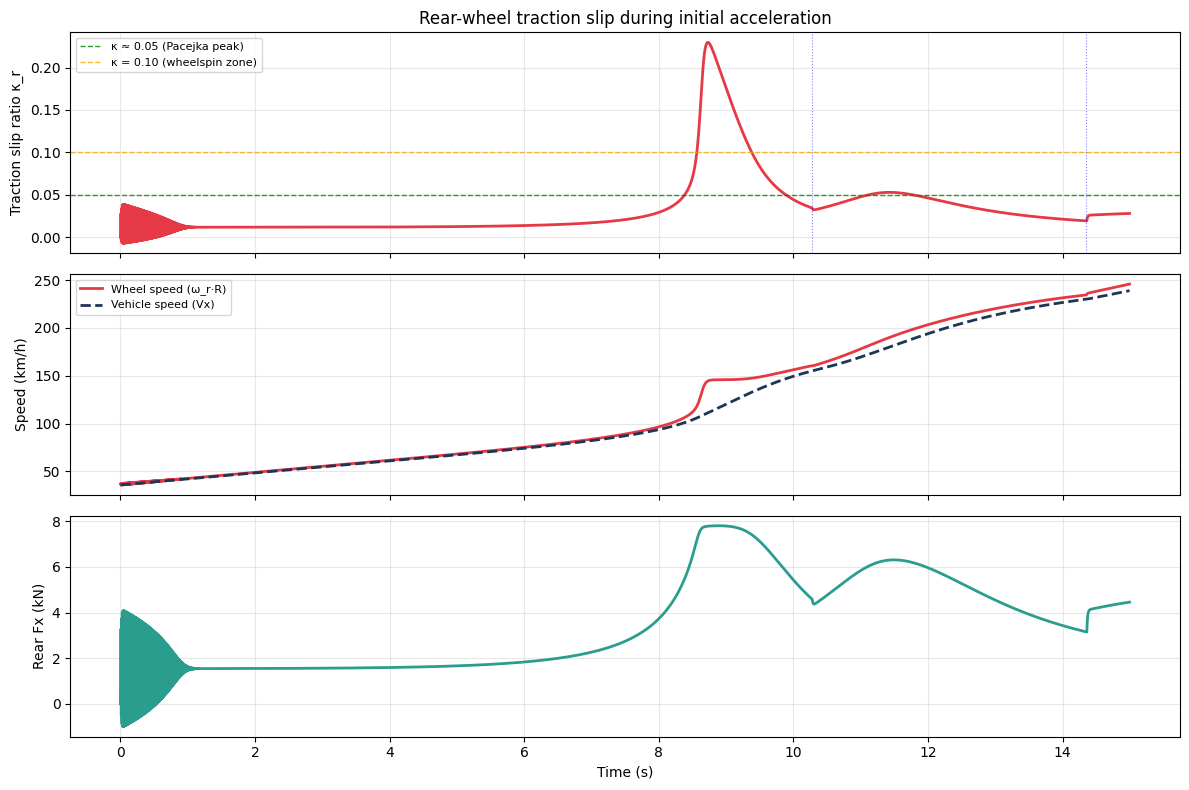

Peak wheelspin: κ = 0.230
  at t=8.730s,  Vx=111.3 km/h
  Wheel speed = 144.5 km/h
  RPM = 12158


In [3]:
# Zoom in on the first 15 seconds
mask_early = ha['t'] < 15.0

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# κ_r
ax = axes[0]
ax.plot(ha['t'][mask_early], ha['kappa_r_drive'][mask_early], color='#e63946', lw=2)
ax.axhline(0.05,  color='green',  lw=1, ls='--', alpha=0.8, label='κ ≈ 0.05 (Pacejka peak)')
ax.axhline(0.10,  color='orange', lw=1, ls='--', alpha=0.8, label='κ = 0.10 (wheelspin zone)')
ax.set_ylabel('Traction slip ratio κ_r')
ax.set_title('Rear-wheel traction slip during initial acceleration')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
for i in shift_idx[shift_idx < np.sum(mask_early)]:
    ax.axvline(ha['t'][i], color='blue', lw=0.8, ls=':', alpha=0.5)

# ω_r and Vx/R (rolling-equivalent)
ax = axes[1]
ax.plot(ha['t'][mask_early], ha['omega_r'][mask_early] * WHEEL_RADIUS * 3.6,
        color='#e63946', lw=2, label='Wheel speed (ω_r·R)')
ax.plot(ha['t'][mask_early], ha['Vx'][mask_early] * 3.6,
        color='#1d3557', lw=2, ls='--', label='Vehicle speed (Vx)')
ax.set_ylabel('Speed (km/h)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Rear longitudinal force
ax = axes[2]
ax.plot(ha['t'][mask_early], ha['Fx_r'][mask_early] / 1000, color='#2a9d8f', lw=2)
ax.set_ylabel('Rear Fx (kN)')
ax.set_xlabel('Time (s)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key numbers at peak wheelspin
idx_peak = np.argmax(ha['kappa_r_drive'])
print(f"Peak wheelspin: κ = {ha['kappa_r_drive'][idx_peak]:.3f}")
print(f"  at t={ha['t'][idx_peak]:.3f}s,  Vx={ha['Vx'][idx_peak]*3.6:.1f} km/h")
print(f"  Wheel speed = {ha['omega_r'][idx_peak]*WHEEL_RADIUS*3.6:.1f} km/h")
print(f"  RPM = {ha['rpm'][idx_peak]:.0f}")

---
## 5 — The friction circle

The tyre has a fixed maximum force budget.  The Pacejka combined slip model distributes this between longitudinal (Fx) and lateral (Fy):

$$\left(\frac{F_x}{F_{x,\max}}\right)^2 + \left(\frac{F_y}{F_{y,\max}}\right)^2 \leq 1$$

When you brake *or* accelerate, longitudinal force grows → lateral capacity shrinks.  
This is why a driver on the limit must **trail-brake** into a corner (smoothly release brake as they build lateral G) rather than hard-brake then hard-steer.

We will drive through a throttle-on corner to visualise the operating points on the friction circle.

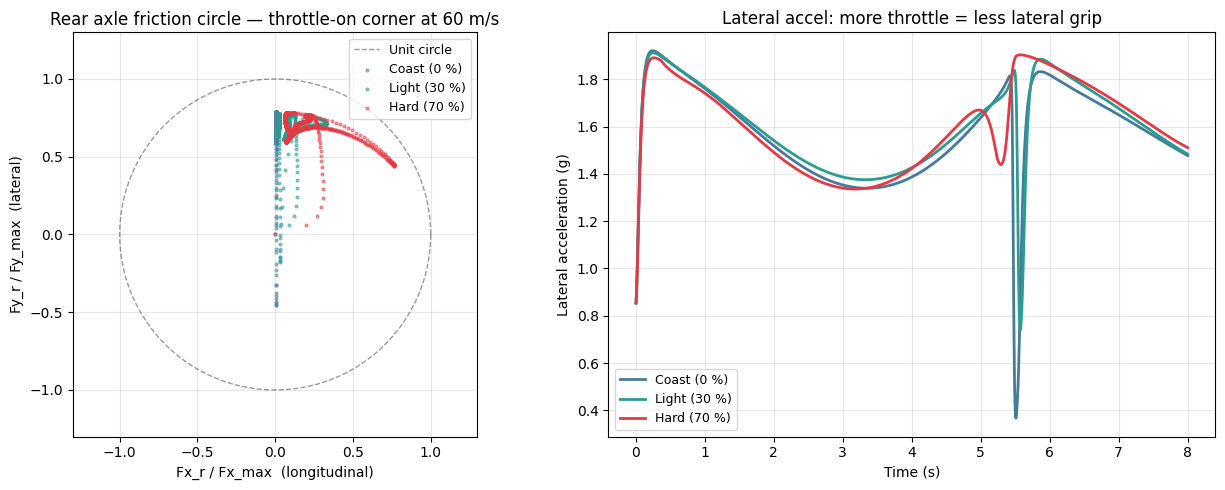

Steady-state lateral accel (last 1 s average):
  Coast (0 %)         : 1.563 g
  Light (30 %)        : 1.577 g
  Hard (70 %)         : 1.601 g


In [4]:
# --- Throttle-on corner: enter at 60 m/s, apply steer + varying throttle
VX0  = 60.0          # m/s
DELTA_RAD = np.radians(3.5)
T_TOT = 8.0
DT    = 0.005
N     = int(T_TOT / DT)

results = {}
for thr_label, thr_val in [('Coast (0 %)', 0.0), ('Light (30 %)', 0.30), ('Hard (70 %)', 0.70)]:
    m = Full2DModel(Vx=VX0)
    for _ in range(N):
        m.step(delta=DELTA_RAD, throttle=thr_val, brake=0.0, dt=DT)
    results[thr_label] = to_h(m)

# Estimate per-axle peak force for normalisation (rear axle at 60 m/s, no cornering)
from bicycle_model import D1, D2, B_LAT, C_LAT, B_LON, C_LON, E_PAC
from pacejka import pacejka

F_down_60 = C_DF * VX0**2
Fz_r_60   = FZ_R + (1 - AERO_BALANCE_F) * F_down_60   # per axle
mu_r_60   = max(0.0, D1 - D2 * (Fz_r_60 / 2))
Fx_r_max  = mu_r_60 * Fz_r_60     # N  (approximate peak)
Fy_r_max  = mu_r_60 * Fz_r_60

# --- Plot friction circle
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#457b9d', '#2a9d8f', '#e63946']

ax = axes[0]
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=1, alpha=0.4, label='Unit circle')
for (label, h), col in zip(results.items(), colors):
    fx_norm = h['Fx_r'] / Fx_r_max
    fy_norm = h['Fy_r'] / Fy_r_max
    ax.scatter(fx_norm, fy_norm, s=4, color=col, alpha=0.5, label=label)
ax.set_xlabel('Fx_r / Fx_max  (longitudinal)')
ax.set_ylabel('Fy_r / Fy_max  (lateral)')
ax.set_title('Rear axle friction circle — throttle-on corner at 60 m/s')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)

# Lateral accel vs time for each throttle level
ax = axes[1]
for (label, h), col in zip(results.items(), colors):
    ax.plot(h['t'], h['ay'] / G, color=col, lw=2, label=label)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Lateral acceleration (g)')
ax.set_title('Lateral accel: more throttle = less lateral grip')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Steady-state lateral accel (last 1 s average):")
for label, h in results.items():
    mask = h['t'] > T_TOT - 1.0
    print(f"  {label:20s}: {np.mean(h['ay'][mask])/G:.3f} g")

---
## 6 — Combined maneuver: chicane with throttle

Now we drive a simple chicane — straight, left, right, straight — with full throttle throughout.  
This exercises every subsystem simultaneously:

- **Aero**: downforce raises grip at 60 m/s entrance
- **Weight transfer**: longitudinal WT under throttle; lateral WT through each apex
- **Combined slip**: tyre is asked for both Fx and Fy at the same time
- **Engine coupling**: throttle increases rear wheel traction slip; corners reduce it back
- **Yaw dynamics**: fast F1 yaw response (Iz = 450 kg·m²) visible in trajectory

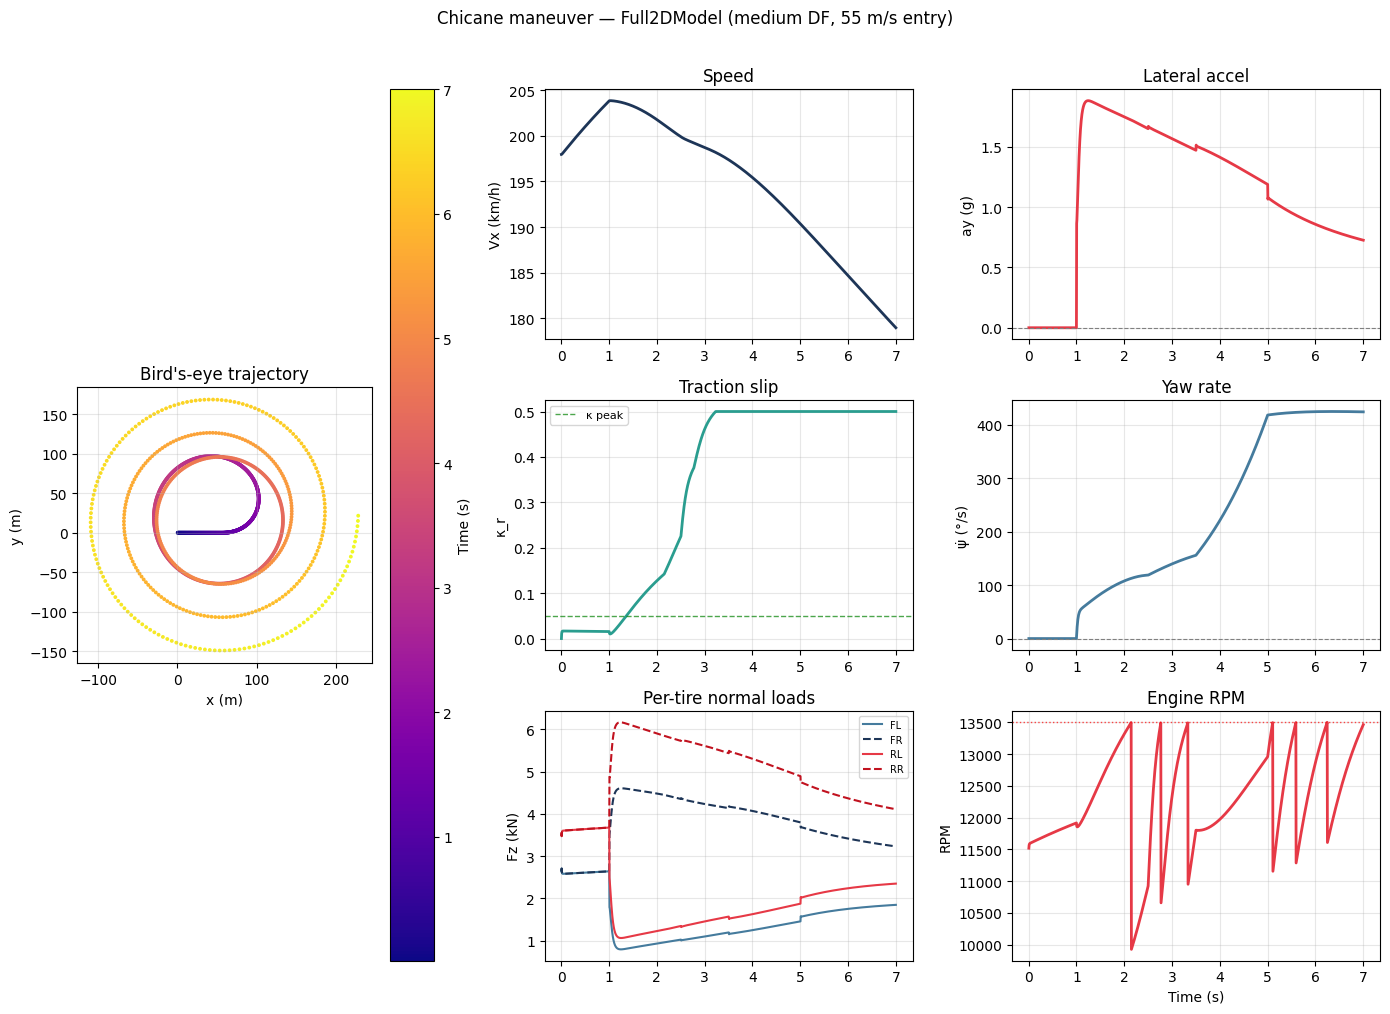

In [6]:
# --- Chicane maneuver: script of (t_end, delta_deg, throttle, brake)
script = [
    (1.0,  0.0,  0.5, 0.0),   # brief half-throttle straight to build speed
    (2.5,  4.0,  0.3, 0.0),   # left turn, light throttle
    (3.5,  0.0,  0.8, 0.0),   # straighten, pickup throttle
    (5.0, -4.0,  0.3, 0.0),   # right turn, light throttle
    (7.0,  0.0,  1.0, 0.0),   # exit: full throttle
]

DT = 0.005
m_chicane = Full2DModel(Vx=55.0)   # medium DF default

t_current = 0.0
for (t_end, delta_deg, thr, brk) in script:
    n_steps = int((t_end - t_current) / DT)
    delta_rad = np.radians(delta_deg)
    for _ in range(n_steps):
        m_chicane.step(delta=delta_rad, throttle=thr, brake=brk, dt=DT)
    t_current = t_end

hc = to_h(m_chicane)

# --- 6-panel plot
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 3, figure=fig)

# Trajectory
ax_traj = fig.add_subplot(gs[:, 0])
sc = ax_traj.scatter(hc['x'], hc['y'], c=hc['t'], cmap='plasma', s=3)
plt.colorbar(sc, ax=ax_traj, label='Time (s)')
ax_traj.set_xlabel('x (m)');  ax_traj.set_ylabel('y (m)')
ax_traj.set_title('Bird\'s-eye trajectory')
ax_traj.set_aspect('equal');  ax_traj.grid(True, alpha=0.3)

# Speed
ax = fig.add_subplot(gs[0, 1])
ax.plot(hc['t'], hc['Vx'] * 3.6, color='#1d3557', lw=2)
ax.set_ylabel('Vx (km/h)');  ax.set_title('Speed');  ax.grid(True, alpha=0.3)

# Lateral accel
ax = fig.add_subplot(gs[0, 2])
ax.plot(hc['t'], hc['ay'] / G, color='#e63946', lw=2)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('ay (g)');  ax.set_title('Lateral accel');  ax.grid(True, alpha=0.3)

# Traction slip
ax = fig.add_subplot(gs[1, 1])
ax.plot(hc['t'], hc['kappa_r_drive'], color='#2a9d8f', lw=2)
ax.axhline(0.05, color='green', lw=1, ls='--', alpha=0.7, label='κ peak')
ax.set_ylabel('κ_r');  ax.set_title('Traction slip');  ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

# Yaw rate
ax = fig.add_subplot(gs[1, 2])
ax.plot(hc['t'], np.degrees(hc['psi_dot']), color='#457b9d', lw=2)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('ψ̇ (°/s)');  ax.set_title('Yaw rate');  ax.grid(True, alpha=0.3)

# Tire loads
ax = fig.add_subplot(gs[2, 1])
ax.plot(hc['t'], hc['Fz_fl'] / 1000, color='#457b9d', lw=1.5, label='FL')
ax.plot(hc['t'], hc['Fz_fr'] / 1000, color='#1d3557', lw=1.5, ls='--', label='FR')
ax.plot(hc['t'], hc['Fz_rl'] / 1000, color='#e63946', lw=1.5, label='RL')
ax.plot(hc['t'], hc['Fz_rr'] / 1000, color='#c1121f', lw=1.5, ls='--', label='RR')
ax.set_ylabel('Fz (kN)');  ax.set_title('Per-tire normal loads');  ax.legend(fontsize=7);  ax.grid(True, alpha=0.3)

# RPM
ax = fig.add_subplot(gs[2, 2])
ax.plot(hc['t'], hc['rpm'], color='#e63946', lw=2)
ax.axhline(RPM_REDLINE * 0.9, color='red', lw=1, ls=':', alpha=0.7)
ax.set_ylabel('RPM');  ax.set_title('Engine RPM');  ax.grid(True, alpha=0.3)
ax.set_xlabel('Time (s)')

plt.suptitle('Chicane maneuver — Full2DModel (medium DF, 55 m/s entry)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

---
## 7 — Oversteer under power: rear-wheel drive tendency

F1 cars are **rear-wheel drive**.  Traction force only comes from the rear tyres.  
Under heavy throttle in a corner:

1. Rear tyres are asked for large Fx (drive) AND Fy (lateral) simultaneously
2. Combined slip reduces both — rear lateral force drops
3. Less rear Fy → yaw moment rotates nose inward → **oversteer**

We demonstrate this by sweeping throttle during a constant steer-angle corner  
and tracking the rear slip angle — a positive increase signals oversteer.

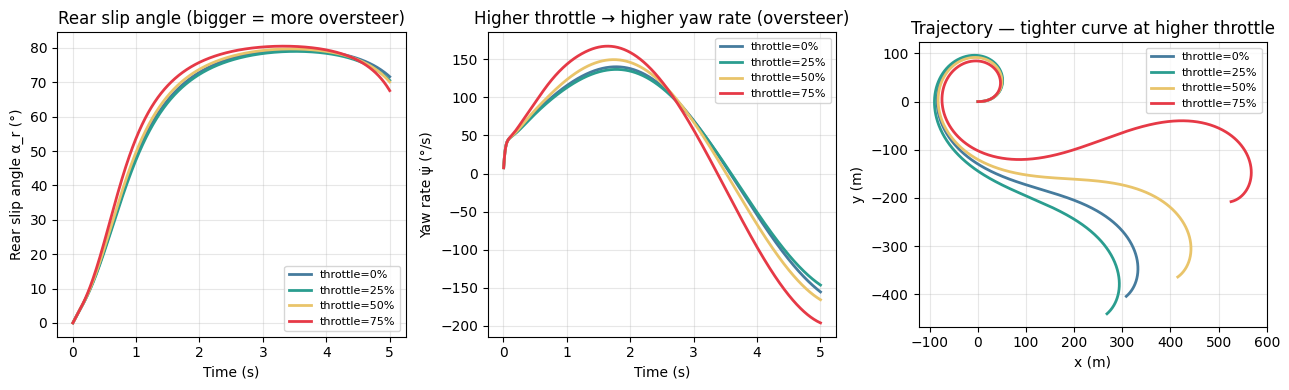

Steady-state rear slip angle (last 0.5 s):
  throttle=0%  α_r=74.65°  ψ̇=-136.08°/s
  throttle=25%  α_r=73.83°  ψ̇=-128.70°/s
  throttle=50%  α_r=73.84°  ψ̇=-148.63°/s
  throttle=75%  α_r=72.78°  ψ̇=-180.96°/s


In [7]:
VX0 = 60.0
DELTA_RAD = np.radians(3.0)
T_SIM = 5.0
DT    = 0.005
N     = int(T_SIM / DT)

throttle_levels = [0.0, 0.25, 0.50, 0.75]
corner_results  = {}

for thr in throttle_levels:
    m = Full2DModel(Vx=VX0)
    for _ in range(N):
        m.step(delta=DELTA_RAD, throttle=thr, brake=0.0, dt=DT)
    corner_results[thr] = to_h(m)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors_thr = ['#457b9d', '#2a9d8f', '#e9c46a', '#e63946']

# Rear slip angle (oversteer indicator)
ax = axes[0]
for thr, col in zip(throttle_levels, colors_thr):
    h = corner_results[thr]
    ax.plot(h['t'], h['alpha_r'], color=col, lw=2, label=f'throttle={thr:.0%}')
ax.set_xlabel('Time (s)');  ax.set_ylabel('Rear slip angle α_r (°)')
ax.set_title('Rear slip angle (bigger = more oversteer)');
ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

# Yaw rate
ax = axes[1]
for thr, col in zip(throttle_levels, colors_thr):
    h = corner_results[thr]
    ax.plot(h['t'], np.degrees(h['psi_dot']), color=col, lw=2, label=f'throttle={thr:.0%}')
ax.set_xlabel('Time (s)');  ax.set_ylabel('Yaw rate ψ̇ (°/s)')
ax.set_title('Higher throttle → higher yaw rate (oversteer)');
ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

# Trajectory
ax = axes[2]
for thr, col in zip(throttle_levels, colors_thr):
    h = corner_results[thr]
    ax.plot(h['x'], h['y'], color=col, lw=2, label=f'throttle={thr:.0%}')
ax.set_xlabel('x (m)');  ax.set_ylabel('y (m)')
ax.set_title('Trajectory — tighter curve at higher throttle');
ax.set_aspect('equal');  ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Steady-state rear slip angle (last 0.5 s):")
for thr in throttle_levels:
    h = corner_results[thr]
    mask = h['t'] > T_SIM - 0.5
    print(f"  throttle={thr:.0%}  α_r={np.mean(h['alpha_r'][mask]):.2f}°  "
          f"ψ̇={np.degrees(np.mean(h['psi_dot'][mask])):.2f}°/s")

---
## 8 — Summary: the complete physics stack

| Notebook | What we built | Key equation |
|----------|--------------|-------------|
| 01 (testing) | Engine, gearbox, 1D acceleration | `F = T × GR × FDR / R` |
| 02 | Slip ratio, longitudinal Pacejka | `Fx = μ(κ) × Fz` |
| 03 | Lateral forces, bicycle model | `Fy = μ(α) × Fz` |
| 04 | Combined slip, friction circle | `σ = √(κ² + tan²α)` |
| 05 | Weight transfer, load sensitivity | `ΔFz_lon = M·ax·hcg/WB` |
| 06 | Aerodynamics | `F_down = C_DF·Vx²` |
| **07** | **Engine coupling, full 2D model** | **`I·dω/dt = T/2 − Fx/2·R`** |

### What's still missing before a driveable pygame simulator

| Feature | Impact | Complexity |
|---------|--------|------------|
| Manual gear control | Driver shifts with paddle — needs clutch model | Low |
| Traction control | Cuts throttle when κ > threshold | Very low |
| Front wheel drive force (0, only steering) | Already correct — F1 is RWD | — |
| Independent left/right rear traction | Differential model | Medium |
| Suspension / ride height | Affects aero balance and roll stiffness | High |
| Track collision / racing line | Circuit boundary conditions | Medium |

### What's already good enough for a pygame game

The `Full2DModel` simulates at **5 ms timesteps (200 Hz)** — well above the 60 Hz needed for smooth rendering.  
A pygame loop calling `model.step()` once per frame will give a physically plausible, responsive F1 car.  

The `settings.py` at the project root will expose `c_df`, `c_dr`, `AERO_BALANCE_F`, `D1`, `D2`, and the gear ratios  
as tunable parameters so you can change the car setup without touching the physics code.